## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from mlxtend.plotting import plot_decision_regions

## Creating Dataset

<function matplotlib.pyplot.show(close=None, block=None)>

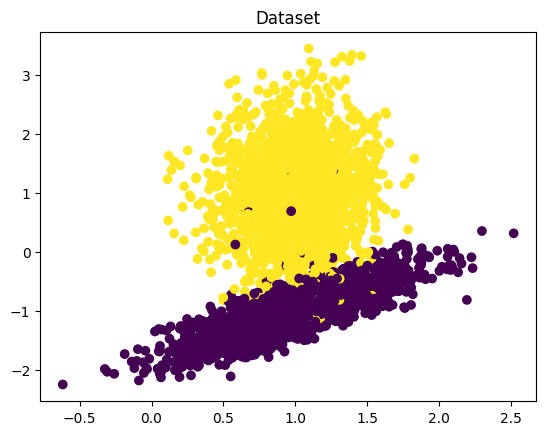

In [15]:
X, y = make_classification(n_samples=4000, n_features=2,
                           n_redundant=0,n_clusters_per_class=1,
                           random_state=0)

plt.scatter(X[:,0],X[:,1],c=y)
plt.title("Dataset")
plt.show

# Implementing Binary Activation function

In [26]:
def binary_activation_func(x):
    return np.where(x >= 0, 1,0)


In [22]:
binary_activation_func(np.array([1,2,-1,-2,0,1]))

array([[1, 0],
       [1, 1],
       [1, 0],
       ...,
       [1, 1],
       [1, 1],
       [1, 0]], shape=(4000, 2))

## Build a Simple Perceptron Model

In [27]:
class BinaryNeuron:

    def __init__(self, lr=0.01, epochs=100):

        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):

            for i in range(len(X)):

                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = binary_activation_func(linear_output)

                error = y[i] - y_pred

                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias
        return binary_activation_func(linear_output)

# Train Model

In [28]:
model = BinaryNeuron(lr=0.01, epochs=100)

model.fit(X, y)

In [29]:
pred = model.predict(X)

print(pred[:10])

[0 1 0 1 1 0 1 0 0 0]


## Visualize Decision Boundary 

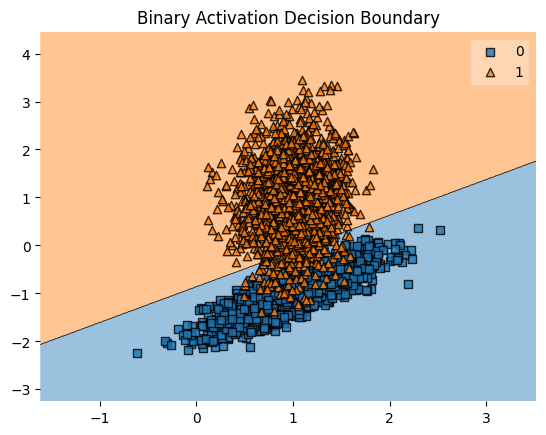

In [30]:
plot_decision_regions(X, y, clf=model)
plt.title("Binary Activation Decision Boundary")
plt.show()